In [ ]:
import networkx as nx
import pickle
import copy
import matplotlib.pyplot as plt
from epidemic_simulation.sir_simulation import fast_SIR
from epidemic_simulation.helpers import *
from sample.helpers import *
from sample.sampling_trees import TreeSampler
from sample.search_on_graphs import feasible_tree

In [8]:
#Loading our example of verification test
with open('data/graphs/verification_test_graph.pickle', mode='rb') as f:
    G = pickle.load(f)

beta = 0.4
fast_SIR(G, [0], beta)

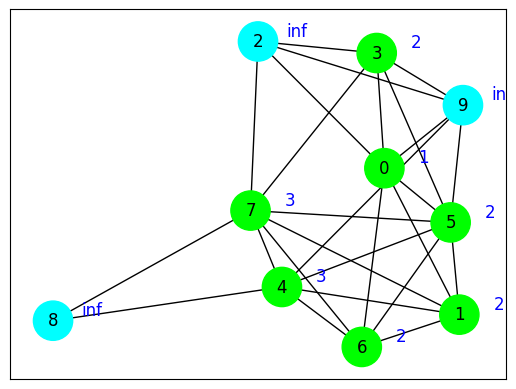

In [9]:
#Visualization of the graph with their respectives infection times
color_state_map = {'recovered': 'lime', 'susceptible': 'cyan'}
node_color = [color_state_map[node[1]['status']] for node in G.nodes(data=True)]

infection_times = nx.get_node_attributes(G, "inf_time")
pos = nx.spring_layout(G, seed = 0)
state_pos = {n: (x + 0.14, y + 0.05) for n, (x,y) in pos.items()}

nx.draw_networkx(G,
                pos,
                node_size = 800,
                node_color = node_color,)

nx.draw_networkx_labels(G, state_pos, labels= infection_times, font_color='blue')
plt.show()

In [10]:
#Making a copy with the real infection times
G_real = copy.deepcopy(G)

#Selecting a fraction of nodes that will not be observed.
p_excluded = 0.4
excluded, infected_nodes = excludeInfTime(G, p_excluded)

#Deleting nodes that we known were not infected from the graph.
delete_susceptibles(G)

T_initial = feasible_tree(G, infected_nodes, flag=1)

In [11]:
if None in T_initial:
    print("Feasible tree not found!")

else:
    print(T_initial)

    samplings_number = 1000

    #Initialize class
    sampler = TreeSamplerMH(G, T_initial, infected_nodes,flag=1)

    #Run
    sampling = sampler.run(n_iterations=samplings_number)
    print(f"Real infection times: {nx.get_node_attributes(G_real, "inf_time")}")
    print("--------------------------------------------------------------------------------------------")
    print(f"Frequency of nodes: {nodes_proportion(G, sampling)}")

[[0], [1, 0], [4, 6, 0], [5, 0], [7, 6]]


Sampling trees:   0%|          | 0/1000 [00:00<?, ?it/s]

Sampling trees:  19%|█▉        | 192/1000 [00:00<00:00, 1907.57it/s]

log-likelihood: -9.193387552578233 
log-likelihood: -13.467436847320599 
log-likelihood: -11.201287691548002 
log-likelihood: -8.059936254228656 
log-likelihood: -8.20044260657837 
log-likelihood: -8.187805582982541 
log-likelihood: -9.695839763907784 
log-likelihood: -11.611670901834403 
log-likelihood: -5.985258707361901 
log-likelihood: -11.138821067325107 
log-likelihood: -6.3692381210437725 
log-likelihood: -13.718859490109253 
log-likelihood: -15.354364726159382 
log-likelihood: -13.921213479156918 
log-likelihood: -20.201919599573458 
log-likelihood: -7.501716014493442 
log-likelihood: -14.47052937651718 
log-likelihood: -15.112833389360246 
log-likelihood: -3.735994996073266 
log-likelihood: -14.108837245140732 
log-likelihood: -13.633196411222075 
log-likelihood: -10.555007491620092 
log-likelihood: -14.378229355289527 
log-likelihood: -6.807772295180313 
log-likelihood: -23.64524302746447 
log-likelihood: -7.378298269299892 
log-likelihood: -9.974636822884978 
log-likelihood:

Sampling trees:  56%|█████▌    | 555/1000 [00:00<00:00, 1366.48it/s]

log-likelihood: -12.431736497473896 
log-likelihood: -12.1407284435683 
log-likelihood: -11.502610488921212 
log-likelihood: -7.446630684623932 
log-likelihood: -5.158727343007426 
log-likelihood: -6.347981655587475 
log-likelihood: -8.715471721694195 
log-likelihood: -6.173273408152443 
log-likelihood: -15.860110423372184 
log-likelihood: -5.416869527005311 
log-likelihood: -6.750120662678523 
log-likelihood: -8.36629018266907 
log-likelihood: -6.098193822861901 
log-likelihood: -5.211037723351816 
log-likelihood: -16.0204491840526 
log-likelihood: -6.1473382359781965 
log-likelihood: -8.985335784524837 
log-likelihood: -19.921617145567023 
log-likelihood: -12.751418555365218 
log-likelihood: -8.43937337520723 
log-likelihood: -8.772570995031966 
log-likelihood: -11.72500488222041 
log-likelihood: -9.184350370755782 
log-likelihood: -4.844877056244411 
log-likelihood: -19.448530174414163 
log-likelihood: -2.761344347844872 
log-likelihood: -5.970277581848112 
log-likelihood: -7.415187

Sampling trees: 100%|██████████| 1000/1000 [00:00<00:00, 1880.64it/s]

log-likelihood: -1.8389854523474902 
log-likelihood: -18.52234239499418 
log-likelihood: -11.745629546987345 
log-likelihood: -7.051324322849365 
log-likelihood: -11.534583977174266 
log-likelihood: -17.016960501859057 
log-likelihood: -10.782923158143761 
log-likelihood: -12.307983891670663 
log-likelihood: -12.379596308797774 
log-likelihood: -6.670170933206114 
log-likelihood: -6.757954215023434 
log-likelihood: -9.255485349230117 
log-likelihood: -19.695742471603197 
log-likelihood: -11.19680153095401 
log-likelihood: -4.866435399261009 
log-likelihood: -12.858199693578669 
log-likelihood: -23.042733604739446 
log-likelihood: -19.5734783923179 
log-likelihood: -8.708943972222801 
log-likelihood: -17.128623715587757 
log-likelihood: -8.610110690883316 
log-likelihood: -12.331290445664804 
log-likelihood: -8.051027006638291 
log-likelihood: -25.60331460390955 
log-likelihood: -7.713823948527357 
log-likelihood: -14.196999527324314 
log-likelihood: -9.08844413387355 
log-likelihood: -

### Plots (visualizing results)
Trace plot

(The drops to low values (e.g., -40) is an indicator of bugs or an instability in the acceptance logic)

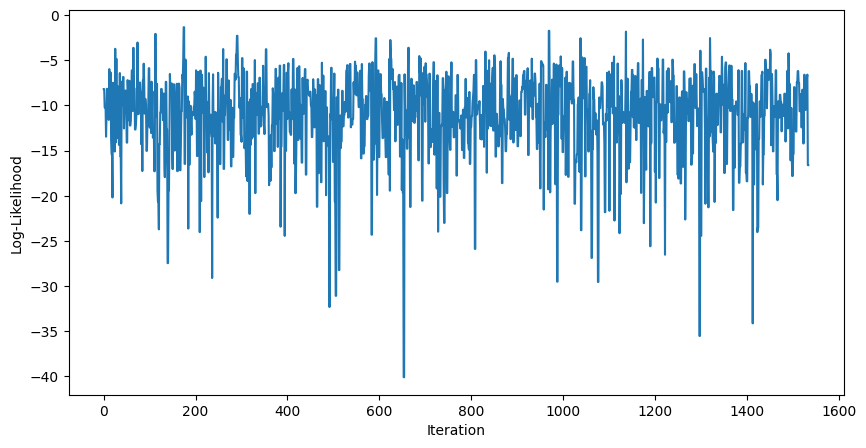

In [12]:
sampler._trace_plot_log_likelihood()